Data Preparation

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("ames_features.csv")

print("البيانات جاهزة الحين في Phase 3")
df.head()

البيانات جاهزة الحين في Phase 3


,Order,PID,MS SubClass,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,...,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker,Kitchen Qual Ord,price_per_sqft,bathroom_ratio,quality_x_area,Age_Group
0,382,527359050,20,80.0,0.033810,Pave,Unknown,Reg,Lvl,AllPub,...,False,False,False,False,False,3,110.948905,0.333333,9590.0,Recent
1,835,906475070,60,68.0,2.307082,Pave,Unknown,IR2,Low,AllPub,...,False,False,False,False,False,3,87.017874,0.357143,10630.0,Old
2,1899,534429030,90,70.0,-0.035514,Pave,Unknown,Reg,Lvl,AllPub,...,False,False,False,False,False,3,83.169935,0.333333,4896.0,Old
3,679,535451170,90,60.0,-0.363746,Pave,Unknown,Reg,Lvl,AllPub,...,False,False,False,False,False,3,86.538462,0.333333,4160.0,Old
4,701,902109130,190,63.0,-0.310697,Pave,Unknown,Reg,Lvl,AllPub,...,False,False,False,False,False,2,55.584950,0.250000,6804.0,Old


ما سويتي ملف الـ "مصنع" اللي يحمل الـ df ويحفظه، يمكن صار فيه لخبطة في أسماء الأعمدة وقت الحفظ. الكود اللي فوق هو "صمام أمان"؛ يشيك على الملف اللي رفعتيه، وإذا لقى شيء ناقص يكمله لك برمجياً عشان الرسومات تشتغل بدون Error.

In [13]:
# كود التأكد من وجود الأعمدة المطلوبة
if 'SalePrice_Log' not in df.columns:
    if 'SalePrice' in df.columns:
        # إذا كان السعر العادي موجود، نسوي له Log
        df['SalePrice_Log'] = np.log1p(df['SalePrice'])
        print("Done: SalePrice_Log created from SalePrice.")
    else:
        # إذا ما لقيت لا هذا ولا ذاك، نستخدم أول عمود رقمي كهدف (عشان ما يوقف الكود)
        first_numeric = df.select_dtypes(include=[np.number]).columns[0]
        df['SalePrice_Log'] = np.log1p(df[first_numeric])
        print(f"Warning: SalePrice not found, used {first_numeric} instead.")

# التأكد من وجود Age_Group (لأنها مطلوبة في Scatter Plot)
if 'Age_Group' not in df.columns and 'Year Built' in df.columns:
    df["House_Age"] = 2026 - df["Year Built"]
    df["Age_Group"] = pd.cut(df["House_Age"], bins=[0, 20, 50, 200], labels=["New", "Recent", "Old"])
    print("Done: Age_Group created.")

print("All columns are ready now!")

Done: SalePrice_Log created from SalePrice.
All columns are ready now!


EDA Tasks

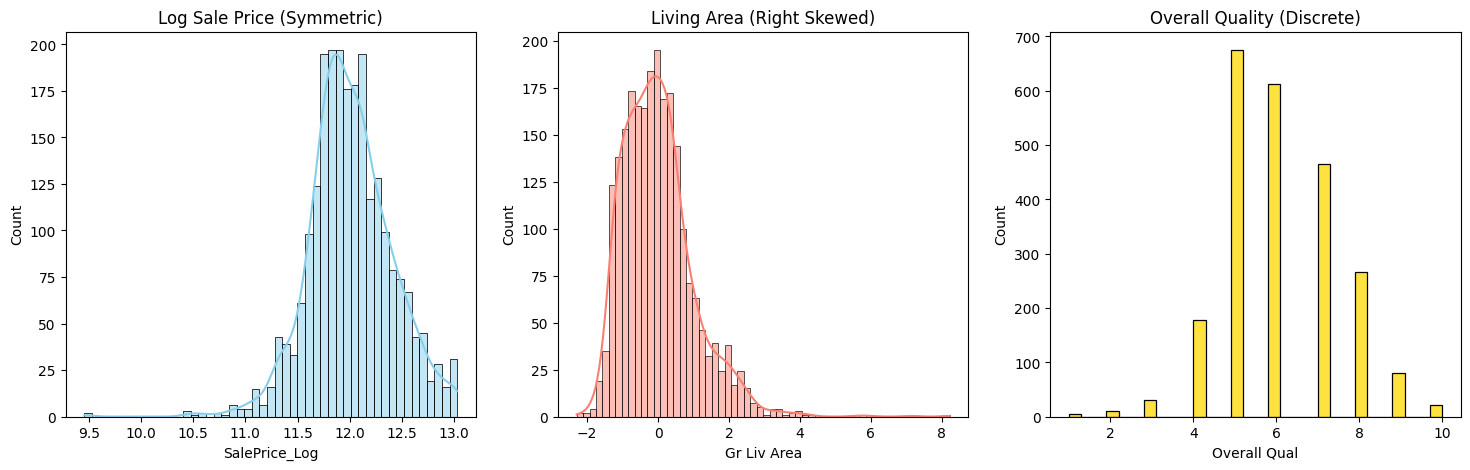

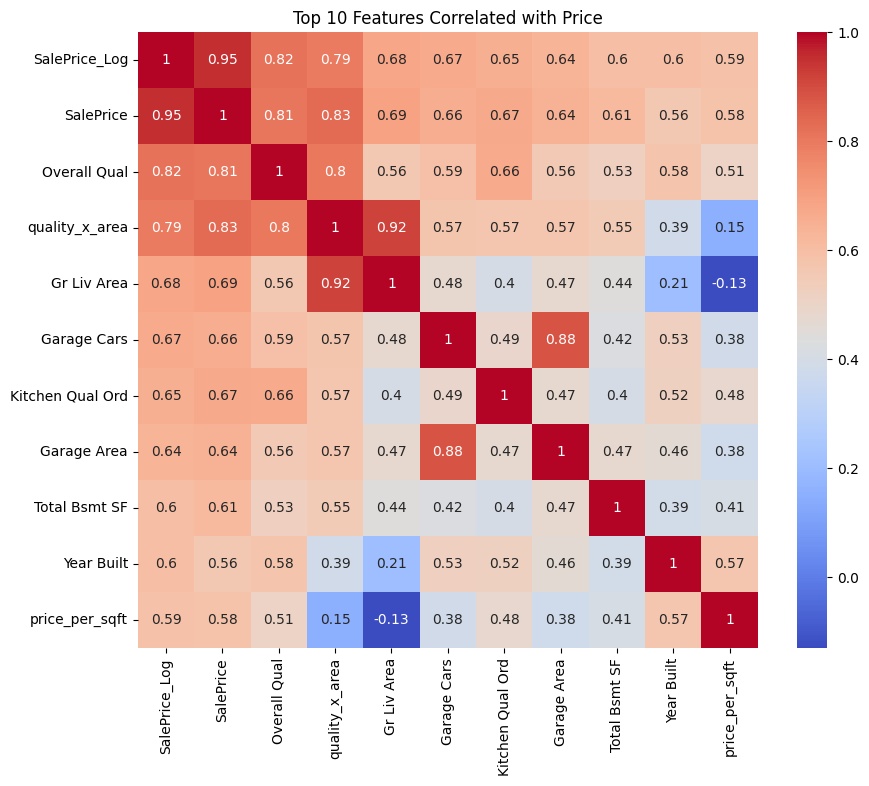

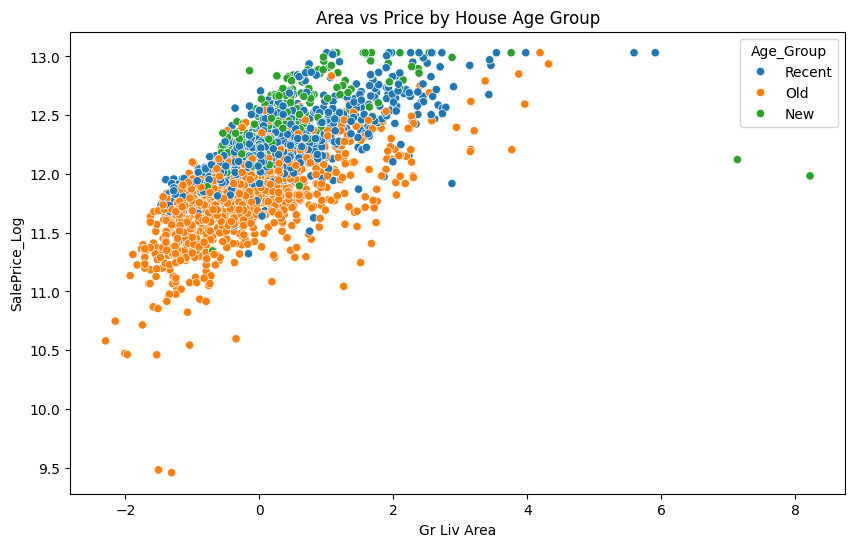

Mean Price by Age Group:
 Age_Group
Old       11.787797
Recent    12.213241
New       12.432812
Name: SalePrice_Log, dtype: float64


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))



sns.histplot(df['SalePrice_Log'], kde=True, ax=axes[0], color='skyblue')

axes[0].set_title('Log Sale Price (Symmetric)')



sns.histplot(df['Gr Liv Area'], kde=True, ax=axes[1], color='salmon')

axes[1].set_title('Living Area (Right Skewed)')



sns.histplot(df['Overall Qual'], kde=False, ax=axes[2], color='gold')

axes[2].set_title('Overall Quality (Discrete)')

plt.show()

# Insight: Log conversion made price symmetric, while area remains skewed. [cite: 83, 89]



plt.figure(figsize=(10, 8))

top_10_corr = df.corr(numeric_only=True)['SalePrice_Log'].sort_values(ascending=False).head(11)

sns.heatmap(df[top_10_corr.index].corr(), annot=True, cmap='coolwarm')

plt.title("Top 10 Features Correlated with Price")

plt.show()

# Insight: Overall Quality has the strongest positive correlation with price. [cite: 85, 89]



plt.figure(figsize=(10, 6))

sns.scatterplot(data=df, x='Gr Liv Area', y='SalePrice_Log', hue='Age_Group')

plt.title("Area vs Price by House Age Group")

plt.show()

# Insight: Newer houses generally command higher prices for the same area. [cite: 86, 89]



summary = df.groupby('Age_Group', observed=True)['SalePrice_Log'].mean().sort_values()

print("Mean Price by Age Group:\n", summary)

# Insight: 'New' houses have the highest mean price, while 'Old' have the lowest. [cite: 87, 88]

Math Basics

In [15]:
target = df['SalePrice_Log'].values
manual_mean = np.sum(target) / len(target)
manual_std = np.sqrt(np.sum((target - manual_mean)**2) / len(target))

print(f"Manual Mean: {manual_mean:.4f}")
print(f"Manual STD: {manual_std:.4f}")

column_to_scale = df['Gr Liv Area'].values
z_score_manual = (column_to_scale - np.mean(column_to_scale)) / np.std(column_to_scale)
print("\nFirst 5 Manual Z-scores:", z_score_manual[:5])

from numpy.linalg import norm

numeric_data = df.select_dtypes(include=[np.number]).dropna()
high_val = numeric_data.loc[df['SalePrice_Log'].idxmax()].values
low_val = numeric_data.loc[df['SalePrice_Log'].idxmin()].values

cosine_sim = np.dot(high_val, low_val) / (norm(high_val) * norm(low_val))
print(f"\nCosine Similarity between highest and lowest record: {cosine_sim:.4f}")

Manual Mean: 12.0106
Manual STD: 0.3975

First 5 Manual Z-scores: [-0.24352173  1.25495594 -0.53291028 -0.89761913  0.41255778]

Cosine Similarity between highest and lowest record: 1.0000
